# Punto 2 — Gráficos de las series originales y estacionariedad

La consigna solicita graficar las series originales, analizar si es necesario diferenciarlas para convertirlas en estacionarias y exponer los conceptos de estacionariedad. En esta etapa la diferenciación se realiza **sin pruebas de hipótesis**; los tests de raíces unitarias corresponden al punto 4.

**Series:** viajes diarios MBTB (Datos Abiertos Rosario), temperatura media a 2 m (°C), humedad relativa a 2 m (%) y precipitación diaria (mm). Intervalo: 1 de enero de 2023 – 31 de diciembre de 2025. Coordenadas: (−60,65; −32,95).


## 1. Carga y preparación


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (12, 4.2),
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "figure.dpi": 110,
    }
)


def project_root() -> Path:
    here = Path.cwd().resolve()
    candidatos = [here, here.parent, here.parent.parent, Path("/workspace")]
    for c in candidatos:
        if (c / "data" / "bicicletas_rosario.csv").exists():
            return c
    raise FileNotFoundError("No se encontró la carpeta data/")


ROOT = project_root()
DATA = ROOT / "data"


def cargar(nombre: str, valor: str, etiqueta: str) -> pd.Series:
    df = pd.read_csv(DATA / nombre, parse_dates=["fecha"])
    s = df.set_index("fecha")[valor].rename(etiqueta).asfreq("D")
    return s


viajes = cargar("bicicletas_rosario.csv", "viajes", "Viajes MBTB")
temp = cargar("temperatura_rosario.csv", "t2m_c", "Temperatura (°C)")
hum = cargar("humedad_rosario.csv", "rh2m_pct", "Humedad relativa (%)")
precip = cargar("precipitacion_rosario.csv", "precip_mm", "Precipitación (mm)")

series = {
    "Viajes MBTB": viajes,
    "Temperatura (°C)": temp,
    "Humedad relativa (%)": hum,
    "Precipitación (mm)": precip,
}

panel = pd.concat(series, axis=1)
print(f"Raíz del proyecto: {ROOT}")
print(f"Observaciones: {len(panel)}  |  {panel.index.min().date()} → {panel.index.max().date()}")
print(f"Valores faltantes por serie:\n{panel.isna().sum()}")
panel.describe().T.round(2)


Raíz del proyecto: /workspace
Observaciones: 1096  |  2023-01-01 → 2025-12-31
Valores faltantes por serie:
Viajes MBTB             0
Temperatura (°C)        0
Humedad relativa (%)    0
Precipitación (mm)      0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Viajes MBTB,1096.0,2566.77,720.64,298.00,2120.00,2615.00,3019.00,4569.00
Temperatura (°C),1096.0,18.84,6.94,1.80,13.53,18.83,24.30,35.50
Humedad relativa (%),1096.0,67.67,14.13,25.86,57.89,69.37,78.70,95.92
Precipitación (mm),1096.0,2.97,9.13,0.00,0.00,0.00,0.91,80.17


## 2. Series originales

Cada panel muestra la trayectoria diaria completa. Sobre viajes se superpone una media móvil de 30 días para resaltar el componente de más baja frecuencia sin sustituir a la serie cruda.


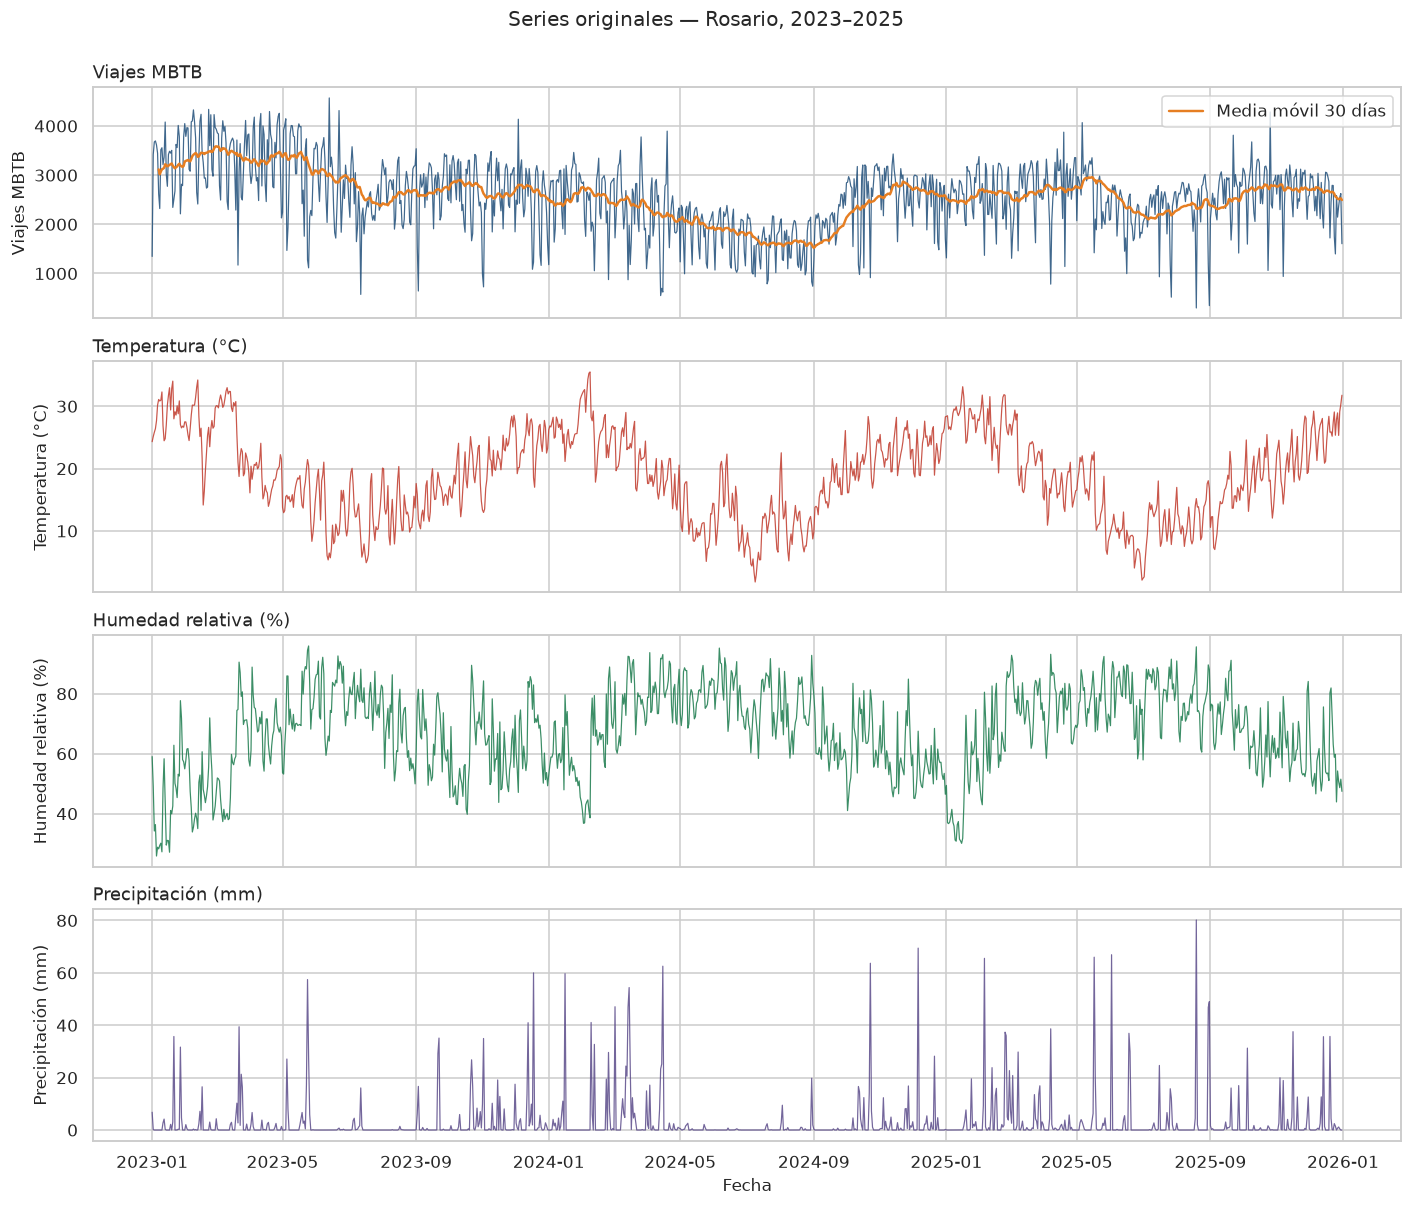

In [3]:
colores = {
    "Viajes MBTB": "#1f4e79",
    "Temperatura (°C)": "#c0392b",
    "Humedad relativa (%)": "#1a7a4c",
    "Precipitación (mm)": "#5b4b8a",
}

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for ax, (nombre, s) in zip(axes, series.items()):
    ax.plot(s.index, s.values, color=colores[nombre], lw=0.8, alpha=0.85)
    if nombre == "Viajes MBTB":
        ax.plot(s.rolling(30, min_periods=7).mean(), color="#e67e22", lw=1.6, label="Media móvil 30 días")
        ax.legend(loc="upper right", frameon=True)
    ax.set_ylabel(nombre)
    ax.set_title(nombre, loc="left", pad=6)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Series originales — Rosario, 2023–2025", y=0.995, fontsize=13)
fig.tight_layout()
plt.show()


### Estacionalidad de calendario (viajes)

El sistema de bicicletas públicas suele responder al ciclo semanal laboral/recreativo y al ciclo anual climático. Los boxplots por día de la semana y por mes permiten ver esas regularidades en la serie original, antes de diferenciar.


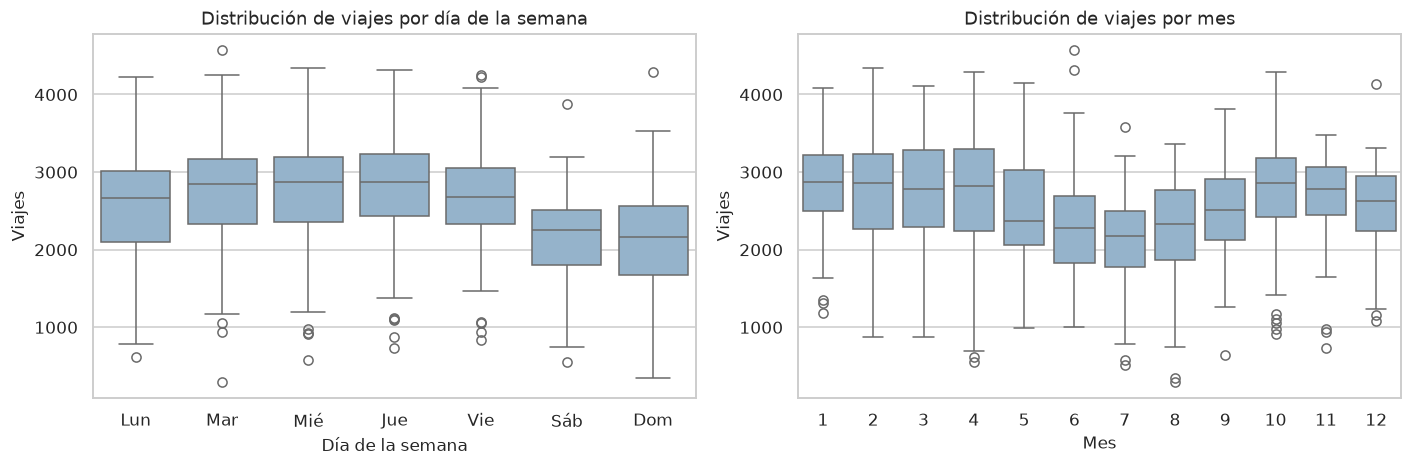

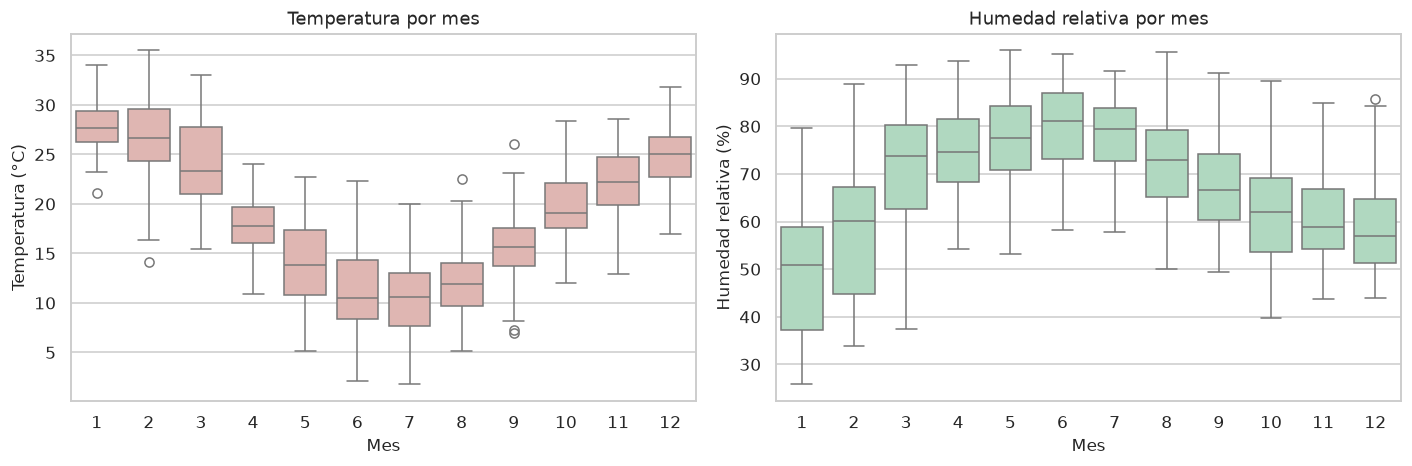

In [4]:
mapa_dias = {0: "Lun", 1: "Mar", 2: "Mié", 3: "Jue", 4: "Vie", 5: "Sáb", 6: "Dom"}
viajes_cal = viajes.to_frame("viajes")
viajes_cal["dia_semana"] = viajes_cal.index.dayofweek.map(mapa_dias)
viajes_cal["mes"] = viajes_cal.index.month
orden_dias = list(mapa_dias.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
sns.boxplot(data=viajes_cal, x="dia_semana", y="viajes", order=orden_dias, ax=axes[0], color="#8cb4d4")
axes[0].set_xlabel("Día de la semana")
axes[0].set_ylabel("Viajes")
axes[0].set_title("Distribución de viajes por día de la semana")

sns.boxplot(data=viajes_cal, x="mes", y="viajes", ax=axes[1], color="#8cb4d4")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Viajes")
axes[1].set_title("Distribución de viajes por mes")
fig.tight_layout()
plt.show()

clima_mes = pd.DataFrame(
    {"Temperatura (°C)": temp, "Humedad relativa (%)": hum}
)
clima_mes["mes"] = clima_mes.index.month

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharex=True)
sns.boxplot(data=clima_mes, x="mes", y="Temperatura (°C)", ax=axes[0], color="#e6b0aa")
sns.boxplot(data=clima_mes, x="mes", y="Humedad relativa (%)", ax=axes[1], color="#a9dfbf")
axes[0].set_title("Temperatura por mes")
axes[1].set_title("Humedad relativa por mes")
for ax in axes:
    ax.set_xlabel("Mes")
fig.tight_layout()
plt.show()


## 3. Conceptos de estacionariedad

Una serie $\{y_t\}$ es **débilmente estacionaria** (estacionaria de segundo orden) cuando se cumplen tres condiciones:

1. **Media constante:** $\mathbb{E}(y_t)=\mu$ para todo $t$.
2. **Varianza finita y constante:** $\mathrm{Var}(y_t)=\sigma^2<\infty$ para todo $t$.
3. **Autocovarianza que depende solo del rezago:** $\mathrm{Cov}(y_t,y_{t-k})=\gamma_k$, y no del momento calendario.

Si alguna de esas propiedades falla, la serie es no estacionaria. En la práctica aparecen tres fuentes habituales:

- **Tendencia determinística:** un componente de tiempo (lineal, cuadrático, estacional fijo) que desplaza la media.
- **Tendencia estocástica (raíz unitaria):** shocks permanentes; la serie se reescribe como un paseo aleatorio (posiblemente con drift). En ese caso la diferenciación regular $\Delta y_t=y_t-y_{t-1}$ es el recurso clásico para recuperar estacionariedad.
- **Estacionalidad:** un ciclo de período $s$ (7 días en datos diarios laborales; 365 días en el clima). La diferenciación estacional es $\Delta_s y_t=y_t-y_{t-s}$.

Una serie puede requerir ambas operaciones: $\Delta\Delta_s y_t$. Diferenciar de más (**sobrediferenciación**) introduce un MA no invertible y suele verse como una serie centrada en cero pero con más ruido de alta frecuencia.

En este punto **no** se aplican tests de Dickey–Fuller, Phillips–Perron ni KPSS. El juicio se apoya en el gráfico de la serie original, en la persistencia visual de nivel/ciclo y en el aspecto de las series ya diferenciadas.


## 4. ¿Es necesario diferenciar? Lectura de las series originales

**Viajes MBTB.** La serie no oscila alrededor de un único nivel: hay un ciclo semanal nítido (caída de fin de semana), un ciclo anual alineado con el clima y cambios de nivel entre años. La media móvil de 30 días se desplaza. Conviene una diferencia regular y, sobre todo, una diferencia estacional semanal ($s=7$).

**Temperatura.** El ciclo anual es el rasgo dominante. No hay un paseo aleatorio evidente; hay un componente estacional de período anual. Una diferencia regular aplana tramos cortos, pero el ciclo de 365 días persiste. La diferenciación estacional anual ($s=365$) es la candidata natural.

**Humedad relativa.** También exhibe estacionalidad anual (más alta en los meses fríos) y oscilaciones de corto plazo. El diagnóstico es análogo al de la temperatura: la diferencia anual es más pertinente que una sola diferencia regular.

**Precipitación.** Es una serie de shocks no negativos, con muchos ceros y picos aislados. Ya se ve media-revertida en el sentido de que los episodios de lluvia no desplazan el nivel de forma permanente. Diferenciarla suele **sobrediferenciar**: aparece una serie centrada en cero, con picos positivos y negativos simétricos que no mejoran la interpretación. En esta etapa no se la trata como serie integrada.


## 5. Series diferenciadas


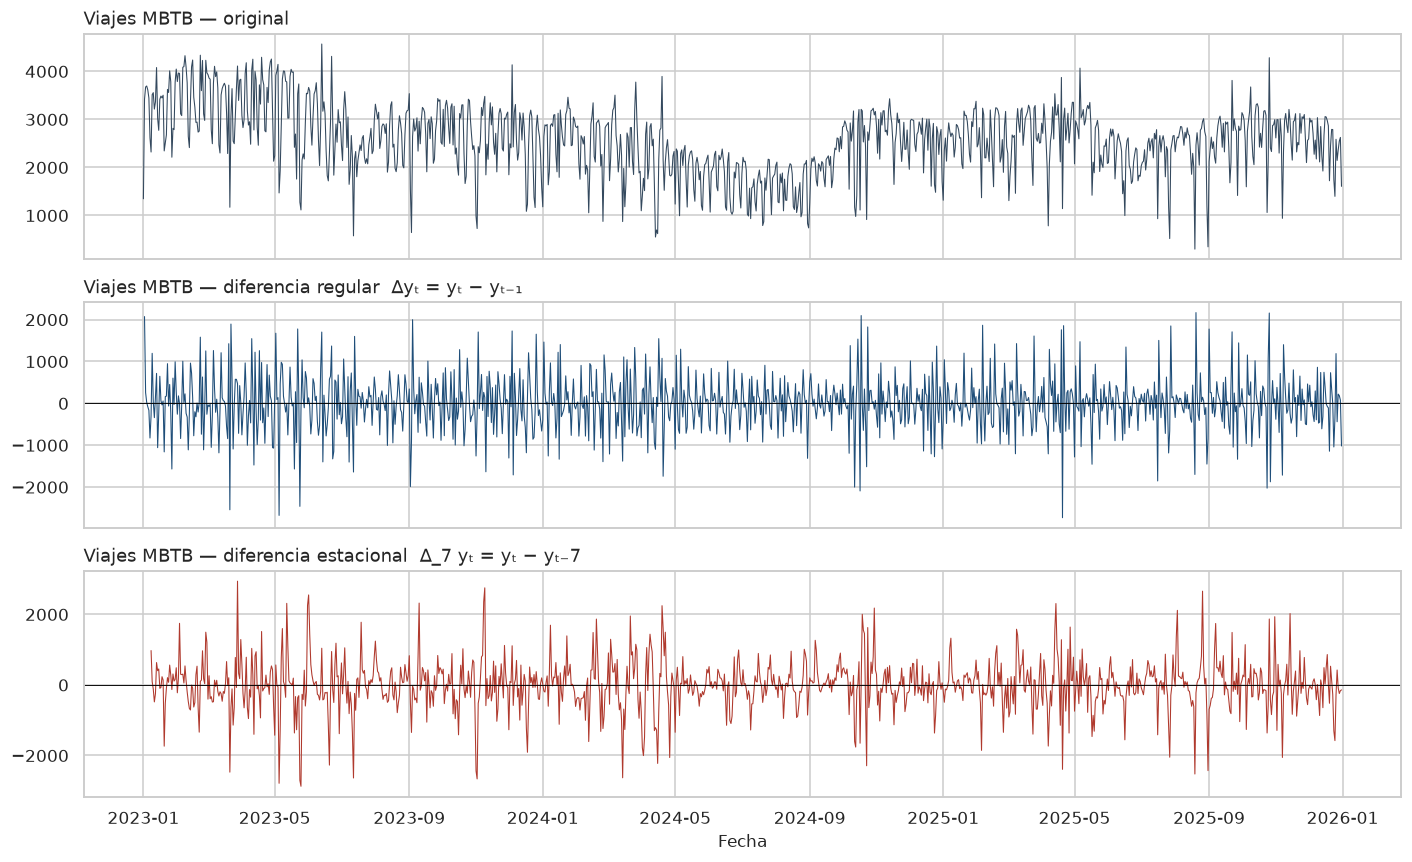

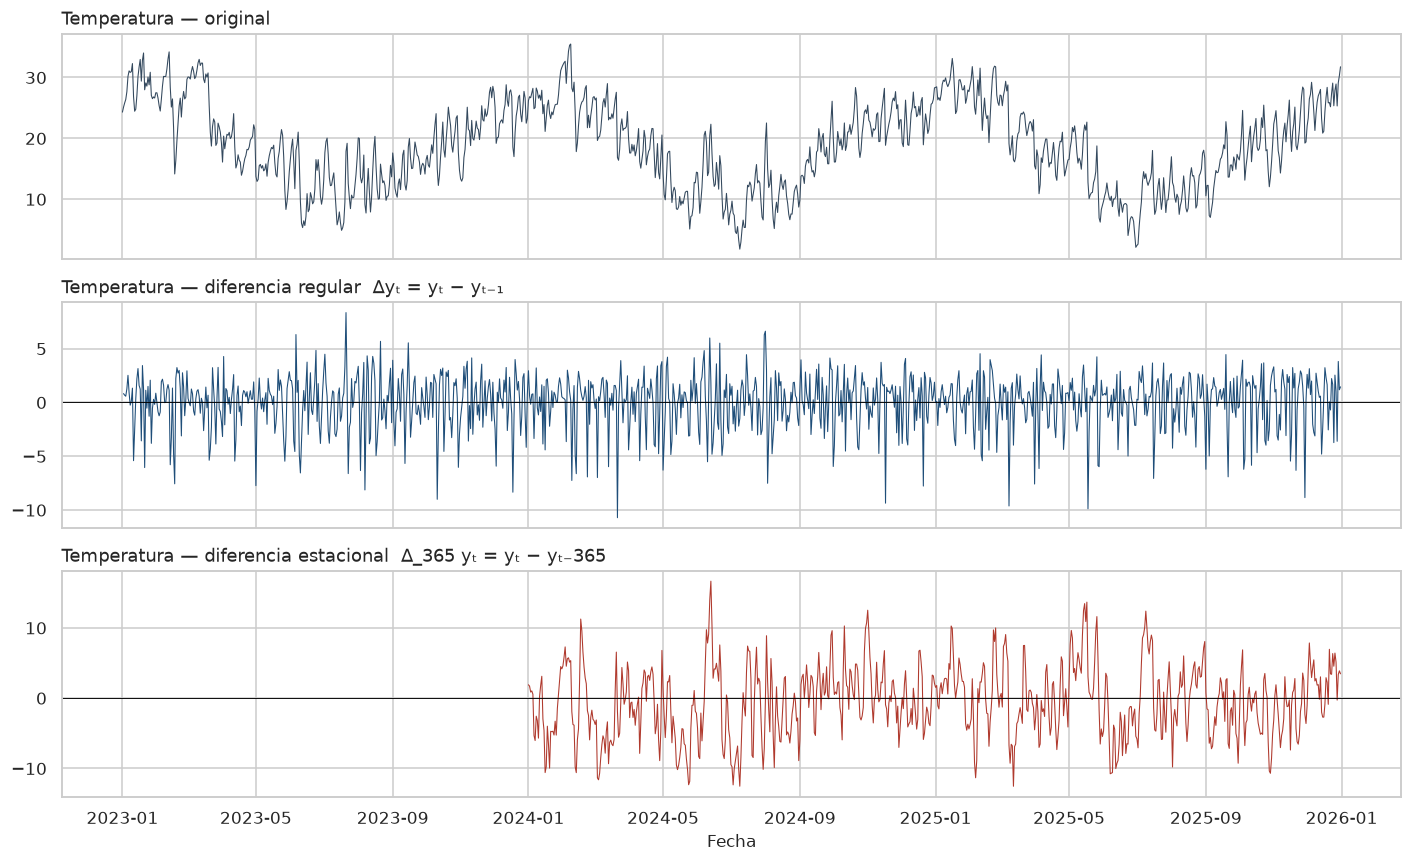

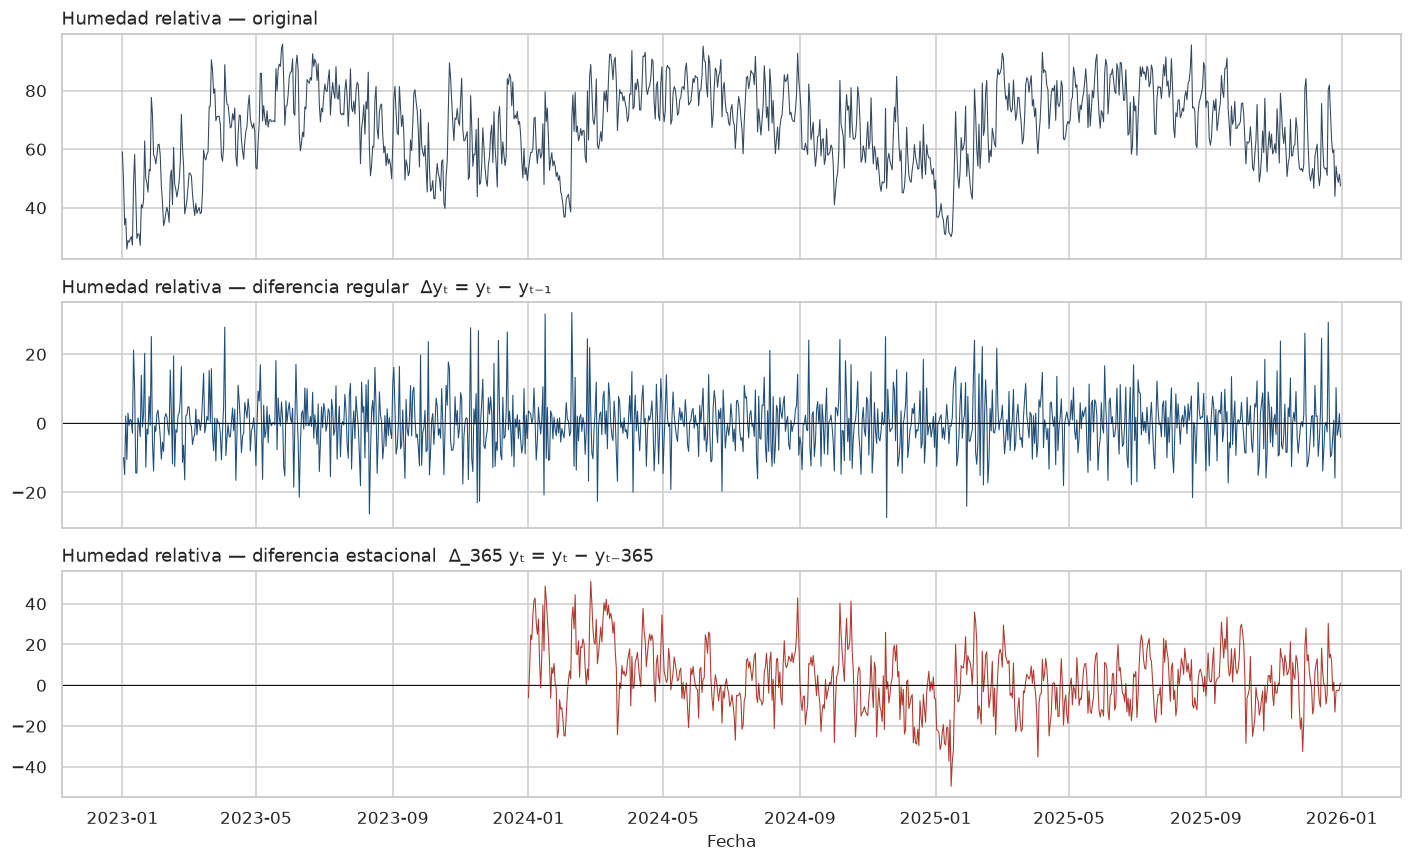

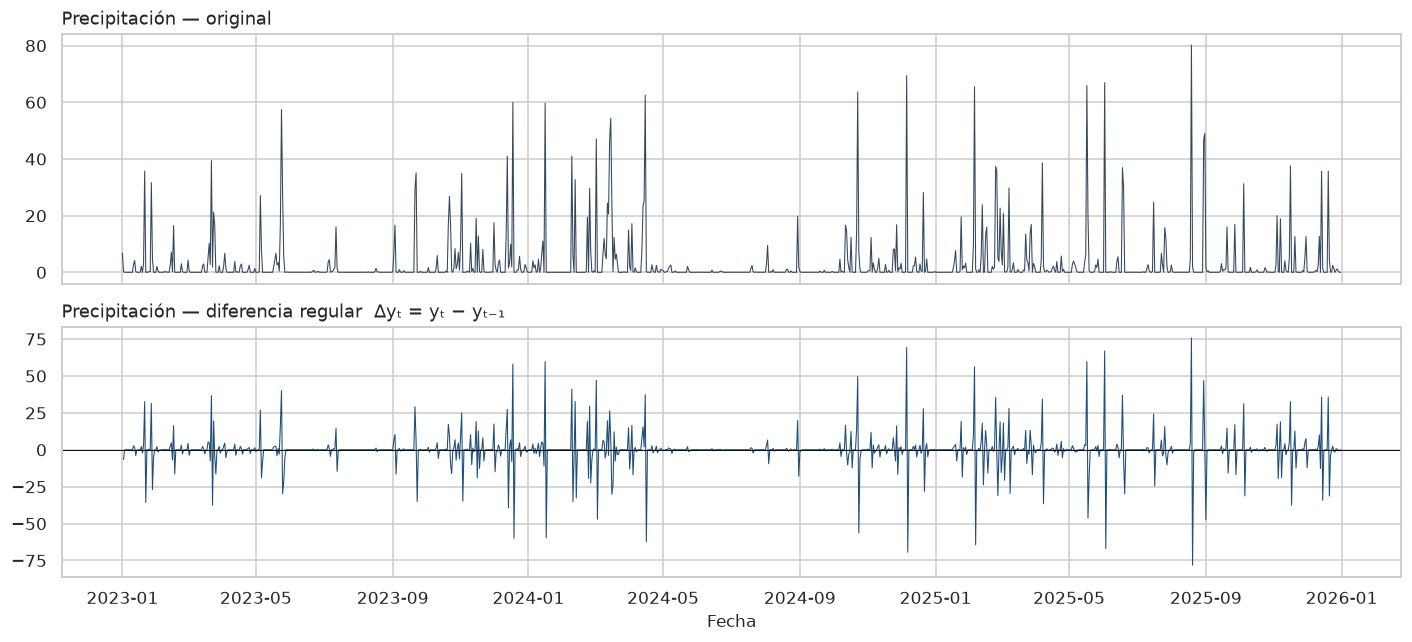

In [5]:
def panel_diferencias(s: pd.Series, titulo: str, s_estacional: int | None = None):
    d1 = s.diff()
    fig, axes = plt.subplots(3 if s_estacional else 2, 1, figsize=(13, 8 if s_estacional else 6), sharex=True)
    axes = np.atleast_1d(axes)

    axes[0].plot(s.index, s.values, color="#34495e", lw=0.7)
    axes[0].set_title(f"{titulo} — original", loc="left")

    axes[1].plot(d1.index, d1.values, color="#1f4e79", lw=0.7)
    axes[1].axhline(0, color="black", lw=0.6)
    axes[1].set_title(f"{titulo} — diferencia regular  Δyₜ = yₜ − yₜ₋₁", loc="left")

    if s_estacional is not None:
        ds = s.diff(s_estacional)
        axes[2].plot(ds.index, ds.values, color="#b03a2e", lw=0.7)
        axes[2].axhline(0, color="black", lw=0.6)
        axes[2].set_title(
            f"{titulo} — diferencia estacional  Δ_{s_estacional} yₜ = yₜ − yₜ₋{s_estacional}",
            loc="left",
        )

    axes[-1].set_xlabel("Fecha")
    fig.tight_layout()
    plt.show()


panel_diferencias(viajes, "Viajes MBTB", s_estacional=7)
panel_diferencias(temp, "Temperatura", s_estacional=365)
panel_diferencias(hum, "Humedad relativa", s_estacional=365)
panel_diferencias(precip, "Precipitación")


### Combinación regular y estacional en viajes

Para la demanda diaria, la operación $\Delta\Delta_7$ (diferencia regular más diferencia semanal) suele dejar una serie más compatible con un ruido de media nula. Se grafica como candidato operativo; la especificación SARIMA se formaliza en el punto 5.


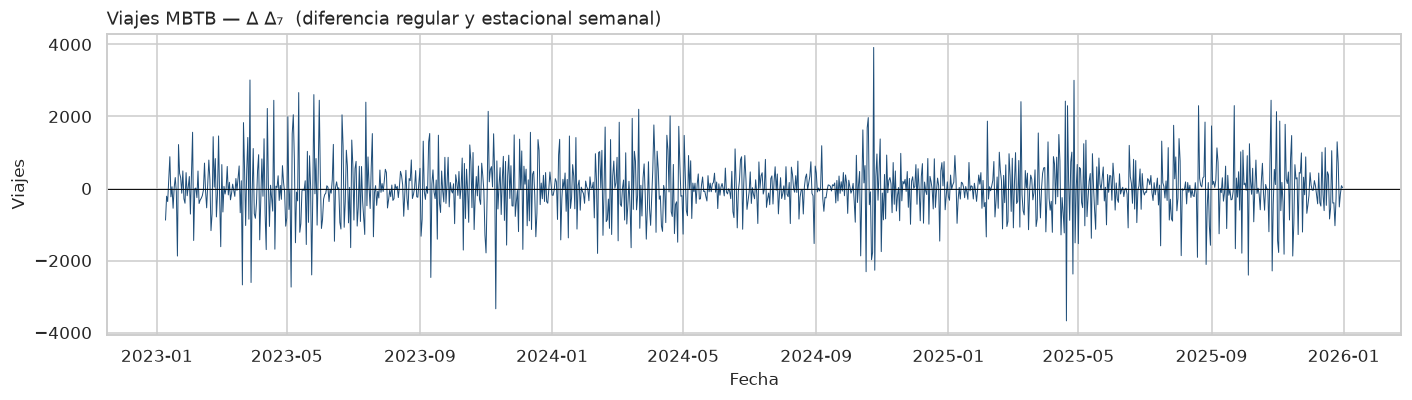

,media,desvio
Original,2566.77,720.64
Δ,0.24,652.47
Δ₇,-6.00,709.72
ΔΔ₇,-1.02,824.38


In [6]:
viajes_d1d7 = viajes.diff().diff(7)

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(viajes_d1d7.index, viajes_d1d7.values, color="#1f4e79", lw=0.65)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Viajes MBTB — Δ Δ₇  (diferencia regular y estacional semanal)", loc="left")
ax.set_xlabel("Fecha")
ax.set_ylabel("Viajes")
fig.tight_layout()
plt.show()

resumen = pd.DataFrame(
    {
        "media": [
            viajes.mean(),
            viajes.diff().mean(),
            viajes.diff(7).mean(),
            viajes_d1d7.mean(),
        ],
        "desvio": [
            viajes.std(),
            viajes.diff().std(),
            viajes.diff(7).std(),
            viajes_d1d7.std(),
        ],
    },
    index=["Original", "Δ", "Δ₇", "ΔΔ₇"],
).round(2)
resumen


## 6. Conclusión del punto 2

| Serie | ¿Estacionaria en nivel? | Diferenciación sugerida (sin test) |
|---|---|---|
| Viajes MBTB | No. Ciclo semanal, ciclo anual y cambios de nivel. | $\Delta$ y $\Delta_7$; evaluar $\Delta\Delta_7$. |
| Temperatura | No en sentido estricto: media estacional anual. | $\Delta_{365}$. La diferencia regular sola no elimina el ciclo. |
| Humedad relativa | No: estacionalidad anual. | $\Delta_{365}$. |
| Precipitación | Compatible con un proceso de media nula/baja, con heteroscedasticidad por ceros y picos. | No diferenciar en esta etapa (riesgo de sobrediferenciación). |

La inspección gráfica alcanza para decidir que **viajes, temperatura y humedad no pueden tratarse como estacionarias en niveles**. La precipitación se reserva en niveles. La confirmación formal queda para las pruebas de raíces unitarias del punto 4 y para la identificación SARIMA del punto 5.
